This is a notebook to test CMOD capabilities of MPPP

In [2]:
import os
import numpy as np
from planetaryimage import PDS3Image
import matplotlib.pyplot as plt
from src2.Image import Image, Frame
from src2.ImProcessor import ImProcessor
# from src2.cmod import *

Text(0.5, 1.0, 'ZR0; SOL709')

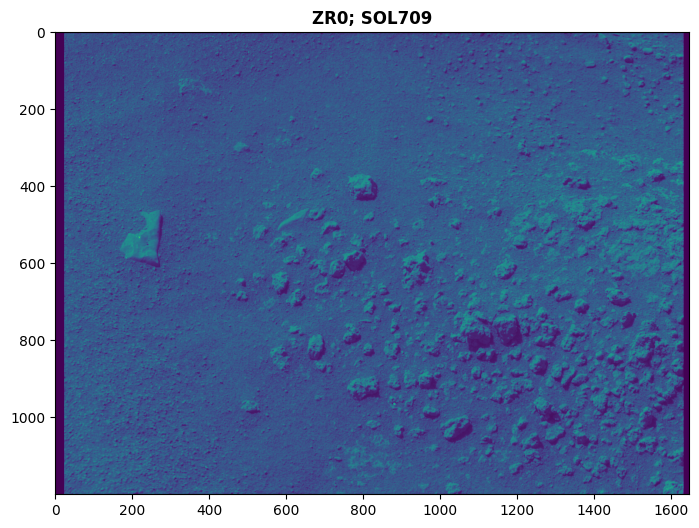

In [6]:
im_path = "./data/ZL0_0709_0729888971_069RAD_N0332864ZCAM07114_0340LMA01.IMG"
im_path = "./data/ZR0_0709_0729888971_069RAD_N0332864ZCAM07114_0340LMA01.IMG"
# im_path = "./data/ZL0_0709_0729889008_069RAD_N0332864ZCAM07114_1100LMA01.IMG"
# im_path = "./data/ZR0_0709_0729889008_069RAD_N0332864ZCAM07114_1100LMA01.IMG"
assert os.path.isfile(im_path), f"File does not exist at {im_path}"

# load the image and the label
pds_im = PDS3Image.open(im_path)
label =  pds_im.label
im = np.float32(pds_im.image)

fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.imshow(np.clip((pds_im.image/pds_im.image.max())*255, 0, 255))
ax.set_title(f"{im_path.split('/')[-1][:3]}; SOL{label['LOCAL_TRUE_SOLAR_TIME_SOL']}", fontweight="bold", fontsize=12)

In [7]:
# from src2.cmod import *

label['GEOMETRIC_CAMERA_MODEL']

PVLGroup([
  ('CALIBRATION_SOURCE_ID', '1')
  ('MODEL_TYPE', 'CAHVOR')
  ('MODEL_COMPONENT_ID', ['C', 'A', 'H', 'V', 'O', 'R'])
  ('MODEL_COMPONENT_NAME',
   ['CENTER', 'AXIS', 'HORIZONTAL', 'VERTICAL', 'OPTICAL', 'RADIAL'])
  ('MODEL_COMPONENT_UNIT', ['METER', 'N/A', 'PIXEL', 'PIXEL', 'N/A', 'N/A'])
  ('MODEL_COMPONENT_1', [0.774598, 0.692667, -1.94501])
  ('MODEL_COMPONENT_2', [0.49721, 0.426035, 0.755839])
  ('MODEL_COMPONENT_3', [-9275.42, 11481.4, 901.039])
  ('MODEL_COMPONENT_4', [-8008.7, -7220.41, 10099.3])
  ('MODEL_COMPONENT_5', [0.510203, 0.413963, 0.753885])
  ('MODEL_COMPONENT_6', [0.000632077, 0.741268, -0.0546172])
  ('MODEL_TRANSFORM_VECTOR', [0.805017, 0.559489, -1.91903])
  ('MODEL_TRANSFORM_QUATERNION', [0.850569, 0.146037, -0.387556, 0.324046])
  ('REFERENCE_COORD_SYSTEM_NAME', 'ROVER_NAV_FRAME')
  ('REFERENCE_COORD_SYSTEM_INDEX', [33, 2864, 12])
  ('INTERPOLATION_METHOD', 'ZOOM')
  ('INTERPOLATION_VALUE', 9600.0)
])

In [19]:
from scipy.spatial.transform import Rotation as R
from enum import Enum



def q_wxyz2xyzw(q_wxyz):
    """
    Converts quaternion with real part at idx 0 to real part at idx 3
    """
    return np.array([q_wxyz[1], q_wxyz[2], q_wxyz[3], q_wxyz[0]])

def cahvor_from_pds( cmod ):
    """
    Converts PDS label to 18 element cahvor vector
    """
    c = cmod['MODEL_COMPONENT_1']
    a = cmod['MODEL_COMPONENT_2']
    h = cmod['MODEL_COMPONENT_3']
    v = cmod['MODEL_COMPONENT_4']
    o = cmod['MODEL_COMPONENT_5']
    r = cmod['MODEL_COMPONENT_6']

    cahvor = cahvor_combine( c,a,h,v,o,r )

    return cahvor

def Rt_mr_from_pds( cmod ):
    """
    Parse the rotation and translation from mast frame to rover frame
    """
    t_mr = cmod['MODEL_TRANSFORM_VECTOR']
    q_mr = q_wxyz2xyzw( cmod['MODEL_TRANSFORM_QUATERNION'] )
    R_mr = R.from_quat( q_mr ).as_matrix()

    return R_mr, t_mr

def cahvor_H( cahvor ):
    """
    Returns a H vector given an 18 element cahvor vector 
    """

    a = cahvor[ 3: 6]
    h = cahvor[ 6: 9]
    v = cahvor[ 9:12]

    H = np.array( [ [ h[0], v[0], a[0] ],
                    [ h[1], v[1], a[1] ],
                    [ h[2], v[2], a[2] ]])

    return H

def cahvor_Hf( cahvor ):
    """
    Returns a fancy H vector given an 18 element cahvor vector
    """
    c = cahvor[ 0: 3]
    a = cahvor[ 3: 6]
    h = cahvor[ 6: 9]
    v = cahvor[ 9:12]

    Hf = np.array( [[ h[0], v[0], a[0], c[0] ],
                    [ h[1], v[1], a[1], c[1] ],
                    [ h[2], v[2], a[2], c[2] ],
                    [    0,    0,    0,   1  ]])

    return Hf   

def cahvor_separate( cahvor ):
    """
    Seperates an 18 elemetn cahvor vector to c, a, h, v, o & r vectors
    """
    c = cahvor[ 0: 3]
    a = cahvor[ 3: 6]
    h = cahvor[ 6: 9]
    v = cahvor[ 9:12]
    o = cahvor[12:15]
    r = cahvor[15:18]

    return c,a,h,v,o,r

def cahvor_combine( c,a,h,v,o,r ):
    """
    Combines individual c,a,h,v,o,r vectors in a single 18 element cahvor vector
    """

    cahvor = np.stack([c,a,h,v,o,r]).flatten()

    return cahvor

def cahvor_intr( cahvor ):

    c,a,h,v,o,r = cahvor_separate( cahvor )

    hs = np.linalg.norm( np.cross( h,a ) )
    vs = np.linalg.norm( np.cross( v,a ) )
    hc = np.dot( h,a )
    vc = np.dot( v,a )

    hp = ( h - hc*a ) / hs
    vp = ( v - vc*a ) / vs
    
    theta = np.arcsin( np.linalg.norm( np.cross( vp, hp ) ))
    if theta>0:
        theta *= -1
    # print( np.rad2deg(theta) )

    f = vs
    b1 = - hs * np.sin(theta) - vs
    b2 =   hs * np.cos(theta)
    cx = hc
    cy = vc

    intr = np.array( f, b1, b2, cx, cy )
    
    return intr

def cahvor_K( cahvor ):

    '''
        This function returns the calibration matrix K from 18 element cahvor vector

        Input:  cahvor model vector
        Output: K_c camera matrix
    '''

    f, b1, b2, cx, cy = cahvor_intr(cahvor)
    K_c = np.array([[ f+b1,  b2,  cx ],
                    [    0,   f,  cy ],
                    [    0,   0,   1 ]])

    return K_c

def cahvor_xyz( cahvor_a ):

    xyz_ac = cahvor_a[ 0: 3]

    return xyz_ac

def find_opk_from_R(R_mat):
    """
    Converts rotation matrix to omega, phi and kappa angles
    """
    # finds omega, phi, kappa from rotation matrix R_cam2site
    R_ = R.from_matrix(R_mat)
    R_cam2ned = R.from_matrix([[0, -1, 0], [1, 0, 0], [0, 0, 1]])
    angles = (R_cam2ned.inv()*R_.inv()).as_euler('XYZ', degrees=1)
    opk = [angles[0], -angles[1], -angles[2]-90]
    return np.array(opk)

def cahvor_opk( cahvor_a ):

    R_ca, _ = cahvor_Rt(cahvor_a)
    opk_ca = find_opk_from_R(R_ca)

    return opk_ca

def cahvor_dist( cahvor ):

    '''
        This function decomposes a cahvor 16-vector into its distortion parameters, in 5-vector (k1,k2,k3,p1,p2)

        Input:  cahvor model vector
        Output: distortion vector
    '''

    c,a,h,v,o,r = cahvor_separate( cahvor )

    k1 = r[1]
    k2 = r[2]
    k3 = 0
    p1 = 0
    p2 = 0

    dist = np.array( [ k1, k2, k3, p1, p2])

    return dist

def cahvor_Rt( cahvor_a ):

    '''
        This function decomposes a cahvor 16-vector into its extrinsic parameters in the form of a matrix and vector. These are the transformation from

        Input:  cahvor model in a-frame
        Output: rotation matrix and offset vector from the camera-frame to a-frame, R_ac and t_ac
    '''
    K_c = cahvor_K( cahvor_a )

    H_c = K_c.T
    H_f = cahvor_H( cahvor_a )
    R_ac = H_f @ np.linalg.inv(H_c)
    t_ac = cahvor_a[ 0: 3]

    return R_ac, t_ac

def cahvor_transform( cahvor_a, R_ba, t_ba ):
    """
    Applies the transformation R_ba and t_ba on cahvor vector in a
    """
    c_a, a_a, h_a, v_a, o_a, r_a = cahvor_dist(cahvor_a)
    c_b = (R_ba @ np.expand_dims(c_a,axis=1) + t_ba).flatten()
    a_b = (R_ba @ np.expand_dims(a_a,axis=1)).flatten()
    h_b = (R_ba @ np.expand_dims(h_a,axis=1)).flatten()
    v_b = (R_ba @ np.expand_dims(v_a,axis=1)).flatten()
    o_b = (R_ba @ np.expand_dims(o_a,axis=1)).flatten()
    r_b  = r_a
    cahvor_b = cahvor_combine(c_b, a_b, h_b, v_b, o_b, r_b)

    return cahvor_b

def Rt_enu( R_a, t_a ):

    '''
    This takes north-east-down frame and returns a east-north-up frame
    '''
    
    R_e = np.array( [[0,1,0],
                     [1,0,0],
                     [0,0,-1]])
    
    R_ae = R_a @ R_e
    t_ae = t_a @ R_e

    return R_ae, t_ae

class Frame(Enum):
    ROVER = 'rover'
    MAST = 'mast'
    ROVER_P = 'rover prime'
    CAMERA = 'camera'
    NAV = 'navigation'
    SITE = 'site'
    NAV_E = 'navigation east'
    SITE_E = 'site east'
    ROVER_E = 'rover east'



def create_cmod( label, frame:Frame = Frame.ROVER, cmod_version=1, cmod_format='cahvor' ):

    # return in a-frame, where "a"

    # model version
    if cmod_version==1:
        # just calculate the cmod from values in label
        cahvor_r = cahvor_from_pds(label)        

    if cmod_version==2:
        raise NotImplementedError("Create CMOD for CMOD V2 is not implemented")


    R_rc, t_rc = cahvor_Rt(cahvor_r)
    R_cr = R_rc.T
    t_cr = (-1 * R_rc.T @ np.expand_dims(t_rc, axis=1)).flatten()
    cahvor_c = cahvor_transform(cahvor_r, R_cr, t_cr)
    # find transform to requested frame
    match(frame):
        case Frame.CAMERA:
            R, t = np.eye(3), np.zeros(3)
        
        case Frame.MAST:
            # R_mc, t_mc = find_Rt_mc(  )
            R_mr, t_mr = Rt_mr_from_pds(label)

            T_mr = np.vstack([np.hstack([R_mr,t_mr]), np.array([0,0,0,1])])
            T_rc = np.vstack([np.hstack([R_rc,t_rc]), np.array([0,0,0,1])])
            T_mc = T_mr @ T_rc
            R, t = T_mc[:3, :3], T_mc[:3, 3]


        case Frame.ROVER_P:
            if cmod_version==1:
                R, t = R_rc, t_rc

            else:
                raise NotImplementedError("Create CMOD for CMOD V2 is not implemented")
                # R_rpc, t_rpc = find_Rt_rpc( )
                # cahvor_a


        case Frame.ROVER:
            # R_rc, t_rc = find_Rt_rc( )
            R, t = R_rc, t_rc

        # TODO: how to find R_nc, t_nc?
        case Frame.NAV:
            R, t = np.eye(3), np.zeros(3)


        # elif frame == 's':

        case Frame.ROVER_E:
            # R_rc,  t_rc  = find_Rt_rc( )
            R, t = Rt_enu( R_rc, t_rc )
            # cahvor_a
        
        case Frame.NAV_E:
            raise NotImplementedError("Create CMOD for NAV_E is not implemented")
            # R_nc,  t_nc  = find_Rt_nc( )
            # R_nec, t_nec = Rt_enu( R_nc, t_nc )
            # cahvor_a
    
        case Frame.SITE_E:
            raise NotImplementedError("Create CMOD for SITE_E is not implemented")
        #     R_sc,  t_sc  = find_Rt_sc( )
        #     R_sec, t_sec = Rt_enu( R_sc, t_sc )
        #     cahvor_a = 

        case _:
            print("Invalid site")
        




    # return cmod in requested format
    if cmod_format == 'cahvor':
        return cahvor_transform(cahvor_c, R, t)
    
    if cmod_format == 'metashape':

        xyz_ae = cahvor_xyz( cahvor_c )
        opk_ae = cahvor_opk( cahvor_c )
        intr_ae = cahvor_intr( cahvor_c )
        dist_ae = cahvor_dist( cahvor_c)

        return xyz_ae, opk_ae, intr_ae, dist_ae
    
    # if cmod_format == 'realitycapture':



In [9]:
# from src2.cmod import *


cmod = label['GEOMETRIC_CAMERA_MODEL']

cahvor_v1_r = cahvor_from_pds( cmod )

cahvor_K_c( cahvor_v1_r )

-6.797419684 84.1219239023


array([[  1.47560625e+04,   8.41219239e+01,   9.60687088e+02],
       [  0.00000000e+00,   1.47628599e+04,   5.75291711e+02],
       [  0.00000000e+00,   0.00000000e+00,   1.00000000e+00]])